<a href="https://colab.research.google.com/github/robinmct/SA2---Implementing-YOLOv26-with-NMS-Free-Detection/blob/main/SA2_YOLOv26_GRP10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# `CSS182-3_CM2` #
### Group 10: ###
#### `Macatangay, Robin Jairic` <br> `Victoriano, Patrick Troy` ####

# SA2 - Implementing YOLOv26 with NMS-Free Detection

This notebook covers the deployment of the YOLOv26 architecture to perform object detection. It includes environment setup, training three different model configurations, and evaluating performance using confusion matrices and statistical metrics.

## 1. Environment Setup

In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Check working directory
import os
# Change this path to where your project folder is located
os.chdir('/content/drive/MyDrive/DS SA2/DS Dataset')
print(os.getcwd())

Mounted at /content/drive
/content/drive/MyDrive/DS SA2/DS Dataset


In [2]:
# Install ultralytics package
!pip install ultralytics

# Verify installation
import ultralytics
ultralytics.checks()

Ultralytics 8.4.23 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 43.5/112.6 GB disk)


**Note:** Ensure your `data.yaml` file correctly points to your training and validation image folders. The path in `data.yaml` should be absolute or relative to the current working directory.

In [3]:
# Verify data.yaml exists
!ls -l data.yaml
# Optional: Print content to check paths
!cat data.yaml

-rw------- 1 root root 339 Mar 16 19:34 data.yaml
train: ../train/images
val: ../valid/images
test: ../test/images

nc: 4
names: ['Car', 'Heavy Vehicle', 'Motorcycle', 'Pedestrian']

roboflow:
  workspace: robins-workspace-rztnr
  project: my-first-project-2cjwp
  version: 2
  license: CC BY 4.0
  url: https://universe.roboflow.com/robins-workspace-rztnr/my-first-project-2cjwp/dataset/2

## 2. Model Initialization & Training

We will train 3 models with different hyperparameter setups:

*   **Model 1:** Epochs: 25, Optimizer: 'AdamW', Batch Size: 4, LR: 0.01
*   **Model 2:** Epochs: 30, Optimizer: 'SGD', Batch Size: 20, LR: 0.001
*   **Model 3:** Epochs: 40, Optimizer: 'auto', Batch Size: -1 (Auto), LR: 0.0001

**Note:** We assume the base model weight file is `yolo26n.pt`. If this is not provided, please ensure it is uploaded or reference a valid YOLO model (like `yolov8n.pt`).

In [4]:
from ultralytics import YOLO

# specific dataset path
data_path = 'data.yaml'
model_base = 'yolo26n.pt'
img_size = 640

### Training Model 1

In [5]:
# Model 1 Configuration
# Epochs: 25, Optimizer: 'AdamW', Batch Size: 4, LR: 0.01

model1 = YOLO(model_base)

results1 = model1.train(
    data=data_path,
    epochs=25,
    imgsz=img_size,
    batch=4,
    optimizer='AdamW',
    lr0=0.01,
    name='model1_run'
)

Ultralytics 8.4.23 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=model1_run3, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=100, perspective=0.0, plots=Tr

### Training Model 2

In [6]:
# Model 2 Configuration
# Epochs: 30, Optimizer: 'SGD', Batch Size: 20, LR: 0.001

model2 = YOLO(model_base)

results2 = model2.train(
    data=data_path,
    epochs=30,
    imgsz=img_size,
    batch=20,
    optimizer='SGD',
    lr0=0.001,
    name='model2_run'
)

Ultralytics 8.4.23 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=20, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=model2_run, nbs=64, nms=False, opset=None, optimize=False, optimizer=SGD, overlap_mask=True, patience=100, perspective=0.0, plots=Tru

### Training Model 3

In [7]:
# Model 3 Configuration
# Epochs: 40, Optimizer: 'auto', Batch Size: -1 (Auto), LR: 0.0001

model3 = YOLO(model_base)

results3 = model3.train(
    data=data_path,
    epochs=40,
    imgsz=img_size,
    batch=-1,     # Auto batching
    optimizer='auto',
    lr0=0.0001,
    name='model3_run'
)

Ultralytics 8.4.23 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=40, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=model3_run, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=T

## 3. Model Evaluation (Confusion Matrix)

After training, we check the confusion matrix to understand the performance.

*   **True Positives:** Diagonal values.
*   **False Positives:** Background errors or class confusion.

Displaying Confusion Matrix for model1_run:


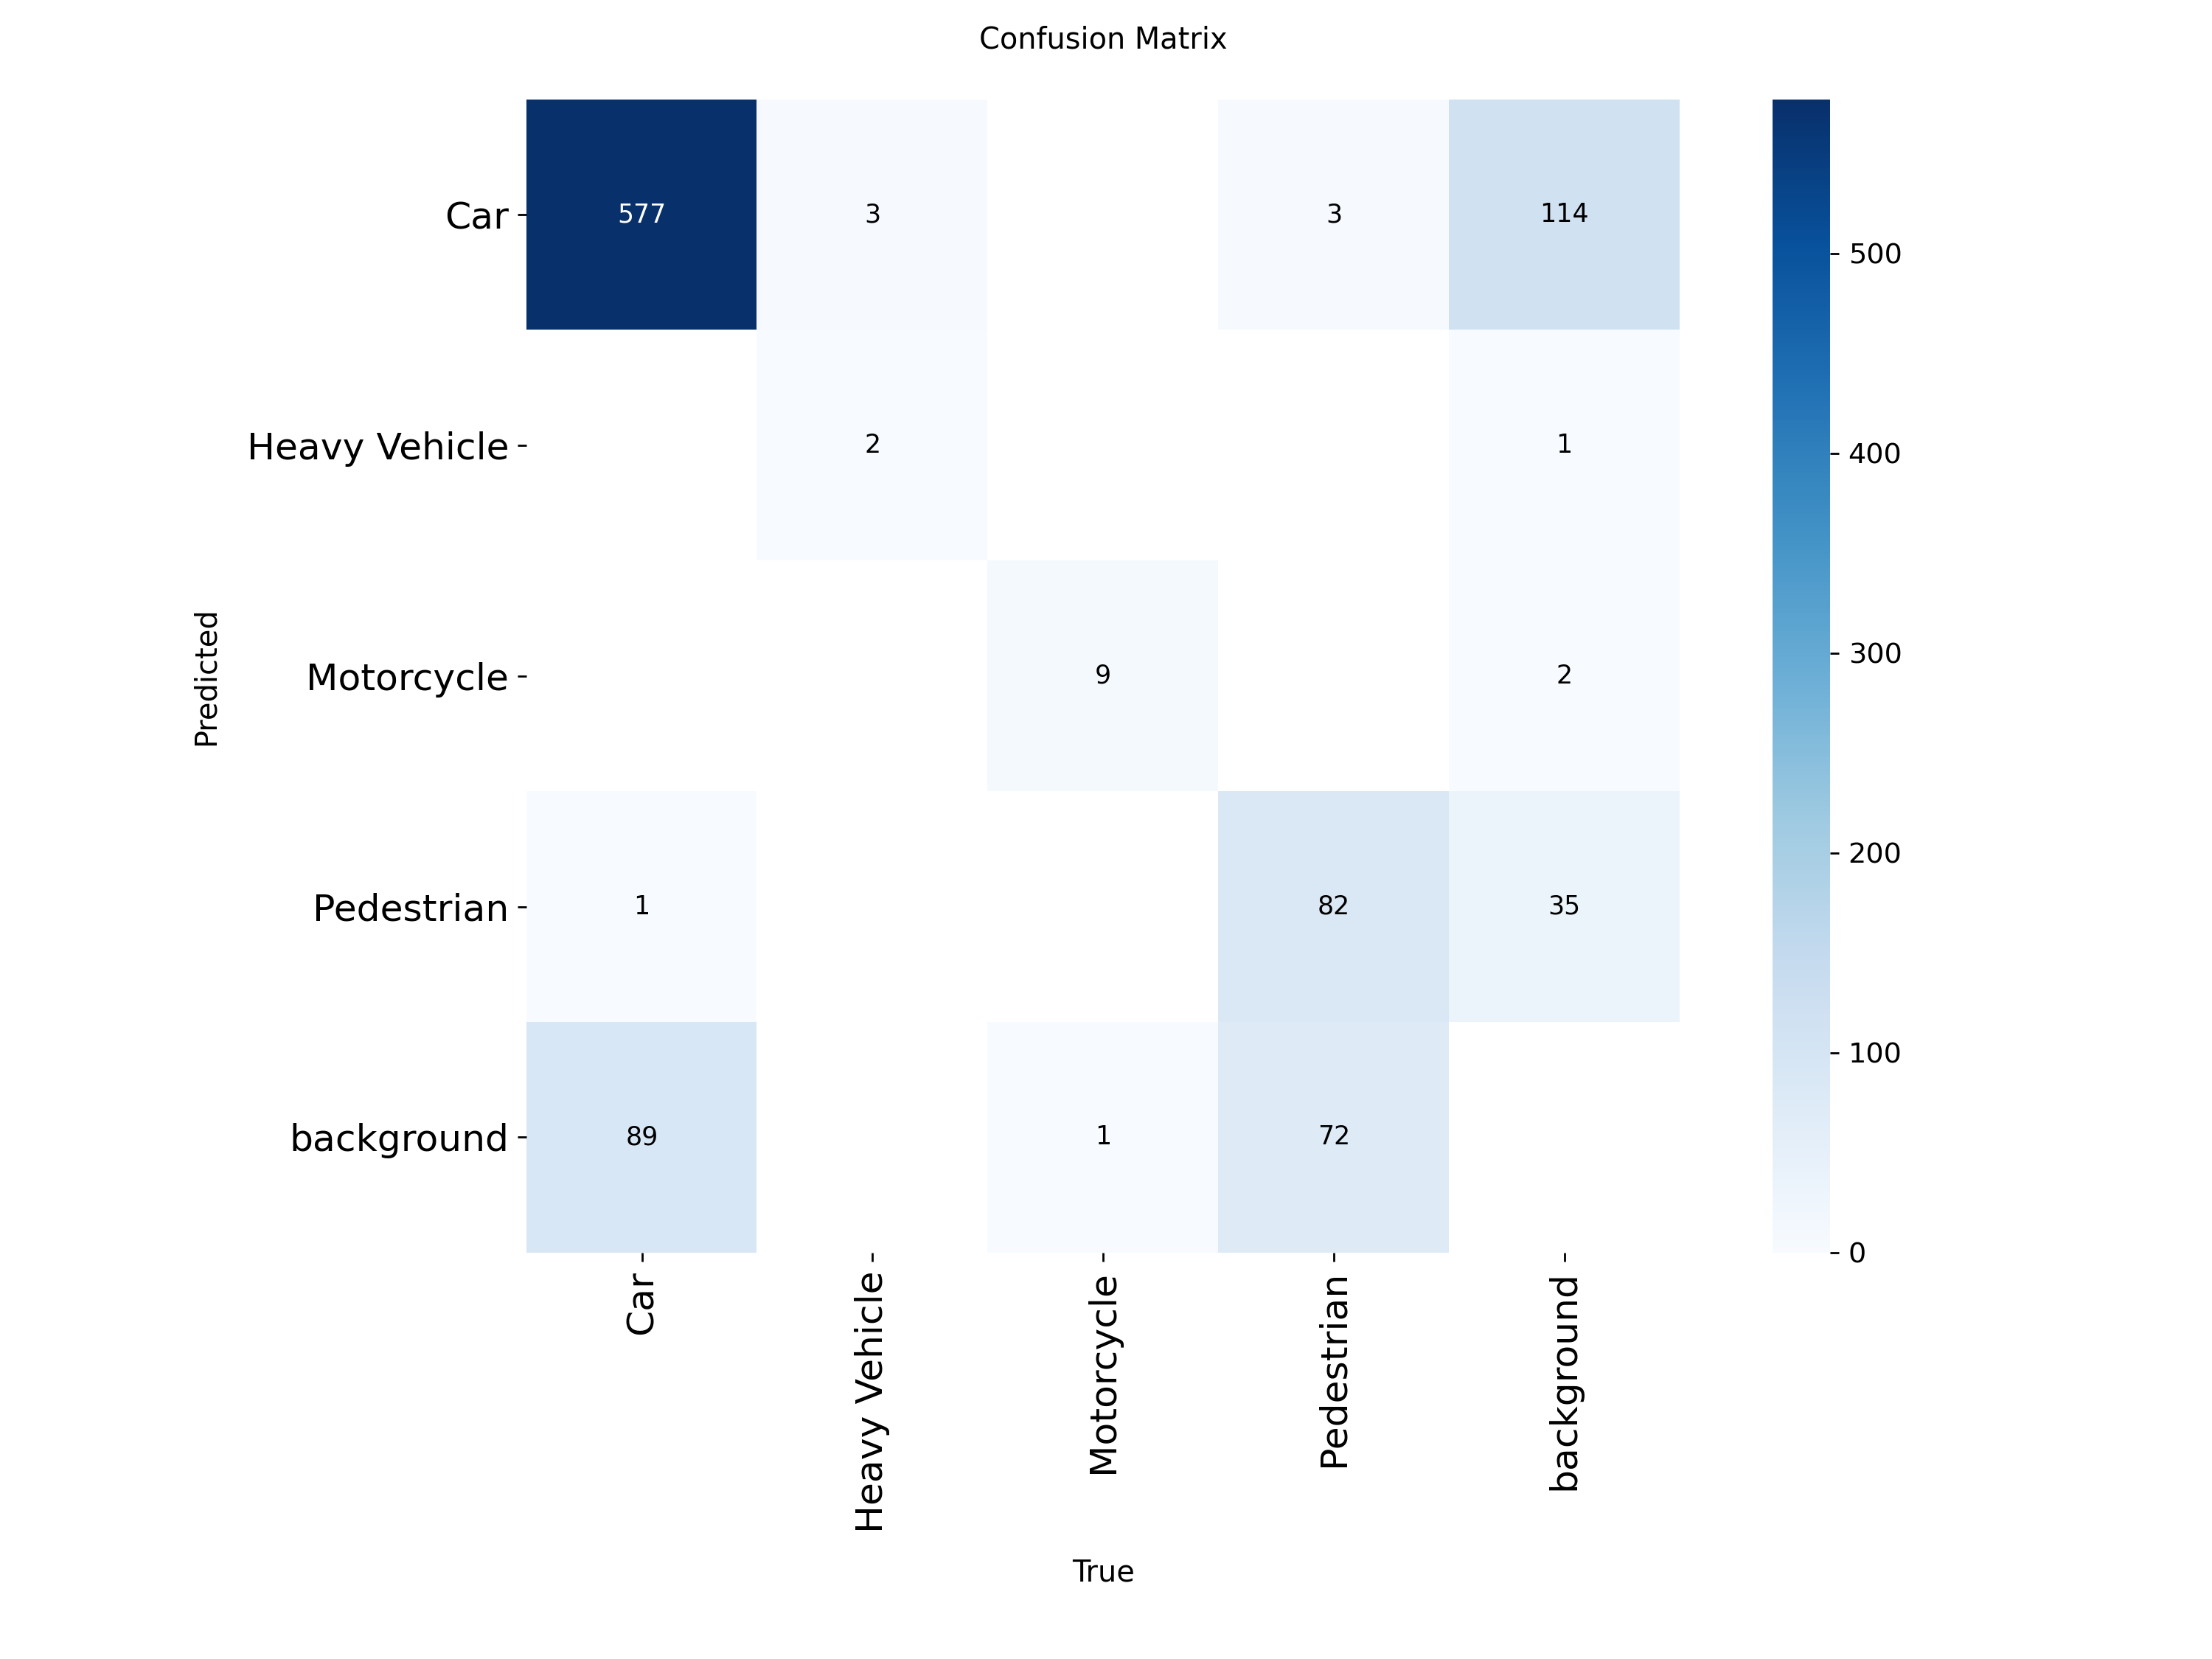

In [18]:
from IPython.display import Image, display
import os

# Helper function to display confusion matrix for a run
def show_confusion_matrix(run_name):
    path = f'runs/detect/{run_name}/confusion_matrix.png'
    if os.path.exists(path):
        print(f"Displaying Confusion Matrix for {run_name}:")
        display(Image(filename=path))
    else:
        print(f"Confusion matrix not found at {path}. Check the output directory.")

# Display for all 3 models
show_confusion_matrix('model1_run')

Displaying Confusion Matrix for model2_run:


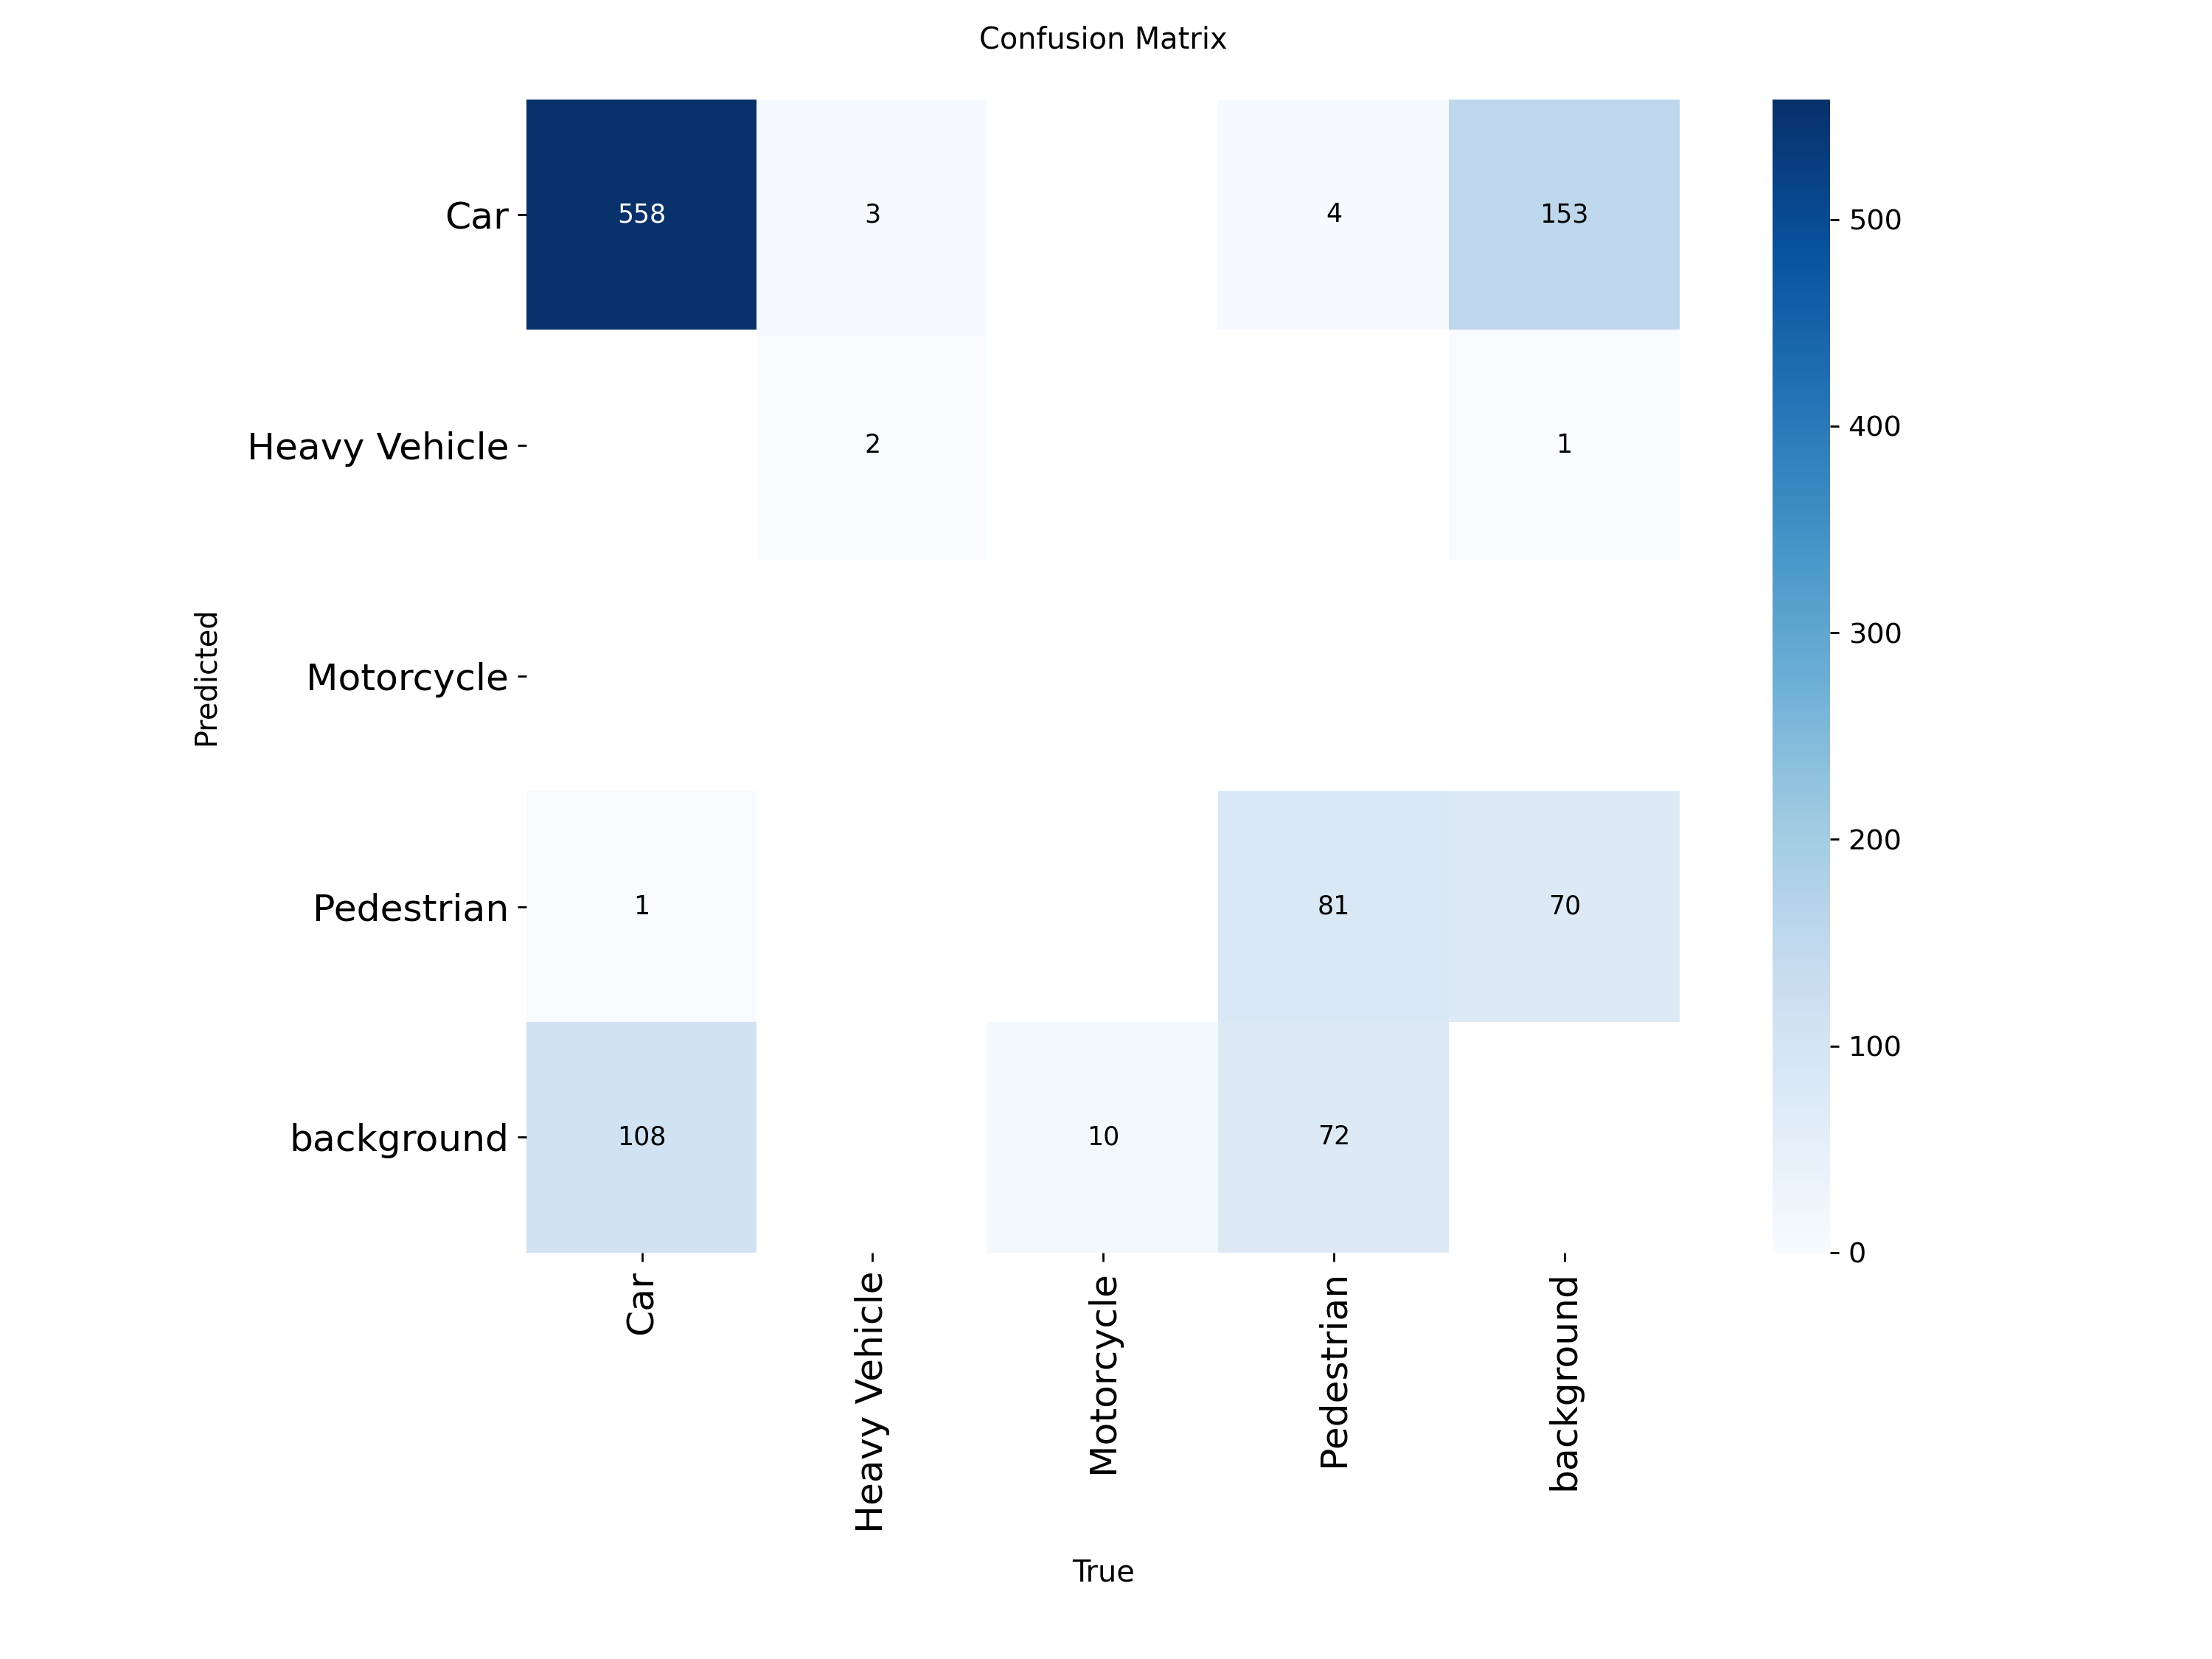

In [19]:
show_confusion_matrix('model2_run')

Displaying Confusion Matrix for model3_run:


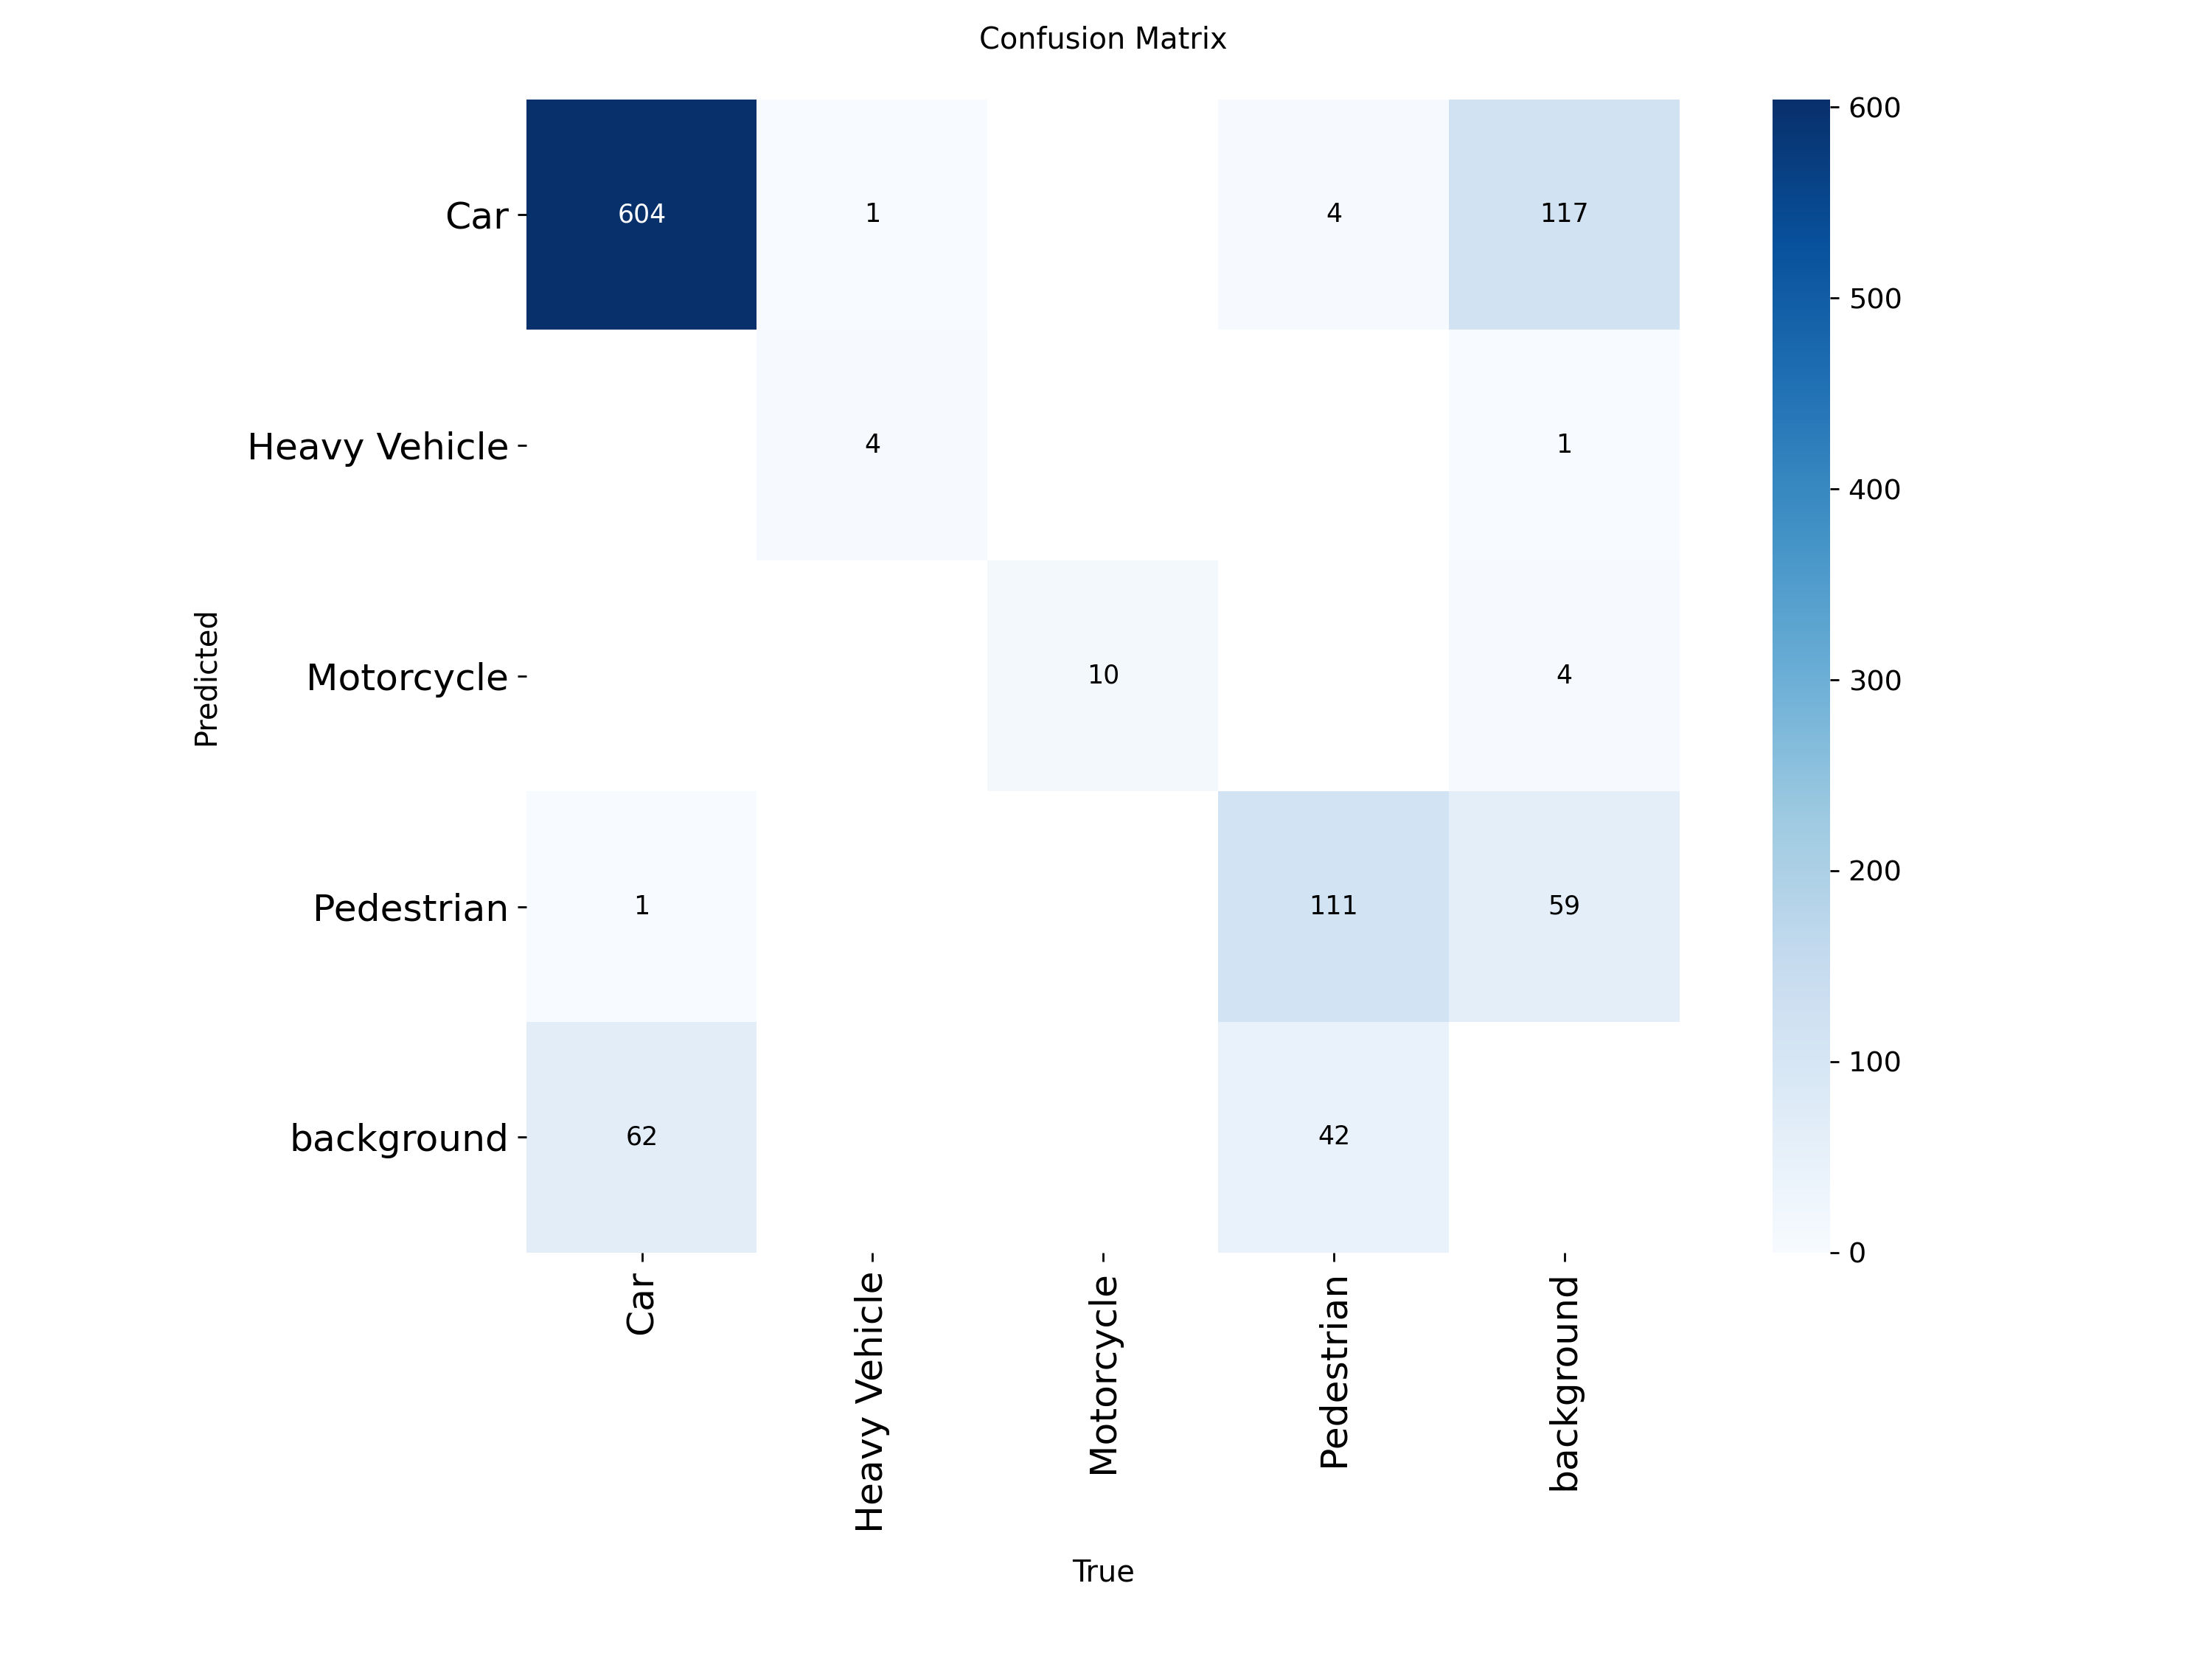

In [20]:
show_confusion_matrix('model3_run')

## 4. Generating Performance Tables

We will now extract the metrics (mAP50, Precision, Recall, F1 Score) and present them in a table.

In [11]:
import pandas as pd

# 1. Hyperparameter Settings Table
hp_data = {
    'Model': ['Model 1', 'Model 2', 'Model 3'],
    'Epochs': [25, 30, 40],
    'Image Size': [640, 640, 640],
    'Batch Size': [4, 20, 'Auto (-1)'],
    'Optimizer': ['AdamW', 'SGD', 'Auto'],
    'Learning Rate': [0.01, 0.001, 0.0001]
}

df_hyperparams = pd.DataFrame(hp_data)
print("Reference: Hyperparameter Settings")
display(df_hyperparams)

Reference: Hyperparameter Settings


,Model,Epochs,Image Size,Batch Size,Optimizer,Learning Rate
0,Model 1,25,640,4,AdamW,0.0100
1,Model 2,30,640,20,SGD,0.0010
2,Model 3,40,640,Auto (-1),Auto,0.0001


In [12]:
# 2. Metrics Results Table

# Function to run validation and extract metrics
def get_validation_metrics(model, model_name):
    print(f"Running validation for {model_name}...")
    metrics = model.val()

    # Ultralytics val() returns a DetMetrics object
    # We can access results via attributes.
    # The .mean_results() method typically returns [P, R, mAP50, mAP50-95]

    md = metrics.mean_results()
    precision = md[0]
    recall = md[1]
    map50_val = md[2]

    # Calculate F1 Score
    # F1 = 2 * (P * R) / (P + R)
    if (precision + recall) > 0:
        f1 = 2 * (precision * recall) / (precision + recall)
    else:
        f1 = 0

    return {
        'Model': model_name,
        'mAP50': map50_val,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1
    }

# Extract metrics (Run validation on each model)
m1_metrics = get_validation_metrics(model1, 'Model 1')
m2_metrics = get_validation_metrics(model2, 'Model 2')
m3_metrics = get_validation_metrics(model3, 'Model 3')

df_results = pd.DataFrame([m1_metrics, m2_metrics, m3_metrics])
print("Performance Metrics")
display(df_results)

Running validation for Model 1...
Ultralytics 8.4.23 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 122 layers, 2,375,616 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access ✅ (ping: 0.6±0.3 ms, read: 57.1±18.9 MB/s, size: 123.1 KB)
val: Scanning /content/drive/MyDrive/DS SA2/DS Dataset/valid/labels.cache... 241 images, 9 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 241/241 50.5Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 50, len(boxes) = 839. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 16/16 2.7it/s 5.9s
                   all        241        839      0.734      0.672      0.754      0.422
                   Car        214        667      0.821       0.87       0.

,Model,mAP50,Precision,Recall,F1 Score
0,Model 1,0.753519,0.733847,0.671670,0.701383
1,Model 2,0.552107,0.775760,0.412073,0.538240
2,Model 3,0.853157,0.877809,0.746090,0.806608


In [21]:
# 3. Per-Class Performance Breakdown
# This cell breaks down performance by class to see the best/worst performing classes.

def show_per_class_performance(model, model_name):
    print(f"\nAnalyzing Class Performance for {model_name}...")
    # Run validation again to get the metric object
    metrics = model.val(verbose=False)

    # Extract per-class metrics
    try:
        # Attributes based on provided error log:
        # ap_class_index (list): Index of class for each AP score.
        # all_ap (list): AP scores for all classes and all IoU thresholds. Shape: (nc, 10).
        # p (list): Precision for each class. Shape: (nc,).
        # r (list): Recall for each class. Shape: (nc,).

        class_indices = metrics.box.ap_class_index
        all_ap_values = metrics.box.all_ap
        precision_values = metrics.box.p
        recall_values = metrics.box.r
        class_names_dict = metrics.names

        data = []
        for i, cls_idx in enumerate(class_indices):
            idx_int = int(cls_idx)
            if idx_int in class_names_dict:
               name = class_names_dict[idx_int]
            else:
               name = f"Class {idx_int}"

            # all_ap is (nc, 10), column 0 is mAP50
            ap50 = all_ap_values[i][0]

            data.append({
                'Class': name,
                'mAP50': float(ap50),
                'Precision': float(precision_values[i]),
                'Recall': float(recall_values[i])
            })

        # Create DataFrame and sort by mAP50 (Best to Worst)
        df_classes = pd.DataFrame(data)
        if not df_classes.empty:
            df_classes = df_classes.sort_values(by='mAP50', ascending=False)
            print(f"Results for {model_name} (Best to Worst):")
            display(df_classes)
        else:
            print(f"No class data found for {model_name}.")

    except Exception as e:
        print(f"Error extracting class metrics for {model_name}: {e}")

# Show for all models
show_per_class_performance(model1, 'Model 1')


Analyzing Class Performance for Model 1...
Ultralytics 8.4.23 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 8.4±17.7 ms, read: 5.6±3.3 MB/s, size: 122.0 KB)
val: Scanning /content/drive/MyDrive/DS SA2/DS Dataset/valid/labels.cache... 241 images, 9 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 241/241 45.9Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 50, len(boxes) = 839. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 16/16 3.0it/s 5.3s
                   all        241        839      0.734      0.672      0.754      0.422
Speed: 2.2ms preprocess, 3.9ms inference, 0.0ms loss, 0.6ms postprocess per image
Results saved to /content/drive/MyDrive/DS SA2/DS Dataset/runs/dete

,Class,mAP50,Precision,Recall
2,Motorcycle,0.950556,0.820254,0.913675
0,Car,0.909999,0.821255,0.869565
1,Heavy Vehicle,0.609530,0.651486,0.400000
3,Pedestrian,0.543992,0.642393,0.503442


In [22]:
show_per_class_performance(model2, 'Model 2')


Analyzing Class Performance for Model 2...
Ultralytics 8.4.23 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.5±0.2 ms, read: 51.0±24.1 MB/s, size: 121.7 KB)
val: Scanning /content/drive/MyDrive/DS SA2/DS Dataset/valid/labels.cache... 241 images, 9 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 241/241 84.2Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 50, len(boxes) = 839. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 16/16 2.6it/s 6.2s
                   all        241        839      0.776      0.412      0.552      0.358
Speed: 3.4ms preprocess, 4.6ms inference, 0.0ms loss, 0.4ms postprocess per image
Results saved to /content/drive/MyDrive/DS SA2/DS Dataset/runs/det

,Class,mAP50,Precision,Recall
0,Car,0.869604,0.836213,0.796061
3,Pedestrian,0.474539,0.613768,0.452229
2,Motorcycle,0.458024,1.000000,0.000000
1,Heavy Vehicle,0.406264,0.653060,0.400000


In [24]:
show_per_class_performance(model3, 'Model 3')


Analyzing Class Performance for Model 3...
Ultralytics 8.4.23 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.4±0.1 ms, read: 48.6±21.3 MB/s, size: 123.2 KB)
val: Scanning /content/drive/MyDrive/DS SA2/DS Dataset/valid/labels.cache... 241 images, 9 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 241/241 72.2Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 50, len(boxes) = 839. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 16/16 3.7it/s 4.3s
                   all        241        839      0.878      0.746      0.853      0.521
Speed: 1.5ms preprocess, 4.0ms inference, 0.0ms loss, 0.4ms postprocess per image
Results saved to /content/drive/MyDrive/DS SA2/DS Dataset/runs/det

,Class,mAP50,Precision,Recall
2,Motorcycle,0.956429,0.924742,0.800000
0,Car,0.931905,0.884872,0.862069
1,Heavy Vehicle,0.895000,0.946848,0.800000
3,Pedestrian,0.629296,0.754776,0.522293


## 5. Discussion of Results

### 1. Which classes did the models struggle with most?

Across all three models, **Heavy Vehicle** and **Pedestrian** were consistently the most difficult classes to detect accurately.

**Heavy Vehicle** suffered from severe class imbalance — the validation set contained only 5 instances across 5 images, compared to 667 Car instances. This scarcity made it nearly impossible for the model to learn robust features for this class. Model 1 achieved a mAP50 of only 0.610, Model 2 achieved 0.406, and even the best-performing Model 3 reached 0.895 only because it had more training epochs and a better-tuned optimizer to compensate.

**Pedestrian** was the second-weakest class in all three models, with mAP50 scores of 0.544, 0.475, and 0.629 for Models 1, 2, and 3 respectively. Pedestrians are visually smaller in traffic scenes, often partially occluded, and may appear in groups, making localization and classification more error-prone.

**Motorcycle** presented a split story: Model 2's SGD optimizer failed catastrophically on this class (Recall = 0.000, meaning the model never successfully recalled a single motorcycle at the confidence threshold used), while Models 1 and 3 both achieved excellent mAP50 scores above 0.950.

**Car** was the strongest class across all models due to its dominant presence in the dataset (667 of 839 validation instances, or ~79.5% of all objects), with mAP50 scores reaching 0.910 (Model 1) and 0.932 (Model 3).

---

### 2. How do the Precision/Recall/F1 scores reflect these struggles?

The Precision/Recall/F1 scores directly reveal the tradeoffs each model made when optimizing under its respective hyperparameter configuration.

**Model 1 (AdamW, LR=0.01, Batch=4)** achieved moderate Precision (0.734) and Recall (0.672), yielding an F1 of 0.701. The relatively balanced P/R ratio suggests that AdamW with a high learning rate converged to a reasonable decision boundary without overfitting to high-confidence predictions. However, the small batch size of 4 introduced high gradient variance, which likely explains the oscillating mAP50 values observed during training (e.g., dropping from 0.698 at epoch 13 back to 0.527 at epoch 11).

**Model 2 (SGD, LR=0.001, Batch=20)** exhibited a notable Precision–Recall imbalance: Precision was high at 0.776, but Recall collapsed to 0.412, producing the lowest F1 score of 0.538. This pattern is a classic symptom of a model that is too conservative — it only predicts detections when it is highly confident, missing many true objects. The Motorcycle class illustrates this extreme: Precision = 1.0 but Recall = 0.0, meaning the model either detected motorcycles perfectly or not at all, suggesting it rarely fired the Motorcycle class. SGD with a low learning rate (0.001) and a relatively large batch likely caused the model to under-explore the loss landscape, settling into a local minimum that favored precision over recall.

**Model 3 (Auto/AdamW, LR=auto→0.00125, Batch=auto→19)** achieved the best balance with Precision of 0.878, Recall of 0.746, and F1 of 0.807. The `optimizer='auto'` setting resolved to AdamW with an adaptively tuned learning rate of 0.00125, which is meaningfully different from the manually set values in Models 1 and 2. The 40-epoch training run allowed the model to continue improving well past the point where Models 1 and 2 stopped — comparing epoch 25/30 losses, Model 3's box loss at epoch 25 was ~1.282 versus Model 1's final loss of ~1.281, but Model 3 continued descending to ~1.069 by epoch 40 — a substantial additional reduction. The per-class breakdown confirms this: Model 3 is the only configuration where all four classes exceeded a mAP50 of 0.62, indicating a more generalized and robust detector.

---

### 3. Which hyperparameter set yielded the best real-world readiness?

**Model 3** (Epochs=40, Optimizer='auto'/AdamW, Batch=-1/Auto≈19, LR=auto→0.00125) is the best candidate for real-world deployment based on every key metric:

| Metric | Model 1 | Model 2 | Model 3 |
|--------|---------|---------|---------|
| mAP50 | 0.754 | 0.552 | **0.853** |
| Precision | 0.734 | 0.776 | **0.878** |
| Recall | 0.672 | 0.412 | **0.746** |
| F1 Score | 0.701 | 0.538 | **0.807** |
| Inference speed | 6.7ms | 3.8ms | **2.9ms** |

Beyond the aggregate metrics, Model 3 is the only model where all four classes are detected at an acceptable level (all mAP50 > 0.62), which is critical for traffic safety applications where failing to detect *any* class (e.g., missing pedestrians or motorcycles) could be dangerous.

The `optimizer='auto'` setting was particularly impactful: it overrode the manually specified `lr0=0.0001` and determined a better learning rate of 0.00125 — more than 12× higher — along with optimal momentum values. This underscores the importance of letting automated hyperparameter selection complement manual tuning. Combined with AutoBatch (which selected batch size 19 for 56% GPU memory utilization), Model 3 used hardware resources efficiently without requiring manual calibration.

The main caveat for deployment is the continued weakness on **Pedestrian** (mAP50=0.629) and the class imbalance in the dataset. Future improvements should focus on collecting additional Heavy Vehicle and Pedestrian examples, applying class-weighted loss, and potentially using data augmentation strategies targeted at underrepresented classes.

## 6. References

Wang, A., Chen, H., Liu, L., Chen, K., Lin, Z., Han, J., & Ding, G. (2024). *YOLOv10: Real-time end-to-end object detection*. arXiv preprint arXiv:2405.14458. https://arxiv.org/abs/2405.14458

Jocher, G., Qiu, J., & Chaurasia, A. (2023). *Ultralytics YOLO* (Version 8.0) [Software]. Ultralytics. https://github.com/ultralytics/ultralytics

Redmon, J., Divvala, S., Girshick, R., & Farhadi, A. (2016). You only look once: Unified, real-time object detection. *Proceedings of the IEEE Conference on Computer Vision and Pattern Recognition (CVPR)*, 779–788. https://doi.org/10.1109/CVPR.2016.91

Loshchilov, I., & Hutter, F. (2019). Decoupled weight decay regularization. *International Conference on Learning Representations (ICLR)*. https://arxiv.org/abs/1711.05101

Robbins, H., & Monro, S. (1951). A stochastic approximation method. *The Annals of Mathematical Statistics*, 22(3), 400–407. https://doi.org/10.1214/aoms/1177729586

Lin, T.-Y., Goyal, P., Girshick, R., He, K., & Dollár, P. (2017). Focal loss for dense object detection. *Proceedings of the IEEE International Conference on Computer Vision (ICCV)*, 2980–2988. https://arxiv.org/abs/1708.02002

Padilla, R., Netto, S. L., & da Silva, E. A. B. (2020). A survey on performance metrics for object-detection algorithms. *2020 International Conference on Systems, Signals and Image Processing (IWSSIP)*, 237–242. https://doi.org/10.1109/IWSSIP48289.2020.9145130

Roboflow. (2024). *Roboflow Universe* [Dataset platform]. https://universe.roboflow.com

Paszke, A., Gross, S., Massa, F., Lerer, A., Bradbury, J., Chanan, G., ... & Chintala, S. (2019). PyTorch: An imperative style, high-performance deep learning library. *Advances in Neural Information Processing Systems (NeurIPS)*, 32. https://arxiv.org/abs/1912.01703